In [1]:
import pdfplumber
from dataclasses import dataclass, field
from typing import Any, Dict, List, Optional, Tuple
import json
import re
from pypdf import PdfReader, PdfWriter
from pypdf.generic import BooleanObject, DictionaryObject, NameObject, NumberObject, TextStringObject


In [2]:
#  commonforms /Users/liuchen/Desktop/pdf_to_form/NUOVO-SCHENGEN-VISA-APPLICATION-FORM.pdf test.pdf


In [3]:
# file = 'NUOVO-SCHENGEN-VISA-APPLICATION-FORM.pdf'

file  = 'ffd_output.pdf'


In [4]:
# ---------- Step 1: 从填充细矩形中提取水平/垂直线 ----------
# 该 PDF 用厚度 ~0.48pt 的填充矩形当线段画方框
LINE_THICKNESS = 2.0   # 厚度小于这个值视为线
MERGE_TOL      = 1.5   # 同一行/列对齐容差
EXTEND_TOL     = 1.5   # 线段端点延伸容差

def extract_lines(page):
    """从 page.rects 中分离出水平线和垂直线。
       返回: h_lines=[(y, x0, x1)], v_lines=[(x, y0, y1)]
    """
    h_lines, v_lines = [], []
    for r in page.rects:
        if not r.get("fill"):
            continue
        w, h = r["width"], r["height"]
        if h < LINE_THICKNESS and w >= LINE_THICKNESS:
            y = (r["y0"] + r["y1"]) / 2
            h_lines.append((y, r["x0"], r["x1"]))
        elif w < LINE_THICKNESS and h >= LINE_THICKNESS:
            x = (r["x0"] + r["x1"]) / 2
            v_lines.append((x, r["y0"], r["y1"]))
    # 也把 stroke 类型的真矩形拆成 4 条边
    for r in page.rects:
        if r.get("stroke") and not r.get("fill"):
            x0, y0, x1, y1 = r["x0"], r["y0"], r["x1"], r["y1"]
            h_lines.append((y0, x0, x1))
            h_lines.append((y1, x0, x1))
            v_lines.append((x0, y0, y1))
            v_lines.append((x1, y0, y1))
    return _merge_lines(h_lines, axis=0), _merge_lines(v_lines, axis=0)

def _merge_lines(lines, axis=0):
    """把同一坐标轴上重叠/相邻的线段合并。"""
    if not lines:
        return []
    # 先按主坐标聚类
    lines = sorted(lines, key=lambda t: (t[0], t[1]))
    clusters = []
    cur = [lines[0]]
    for ln in lines[1:]:
        if abs(ln[0] - cur[-1][0]) <= MERGE_TOL:
            cur.append(ln)
        else:
            clusters.append(cur)
            cur = [ln]
    clusters.append(cur)

    merged = []
    for cl in clusters:
        coord = sum(t[0] for t in cl) / len(cl)
        # 按起点排序后做区间合并
        segs = sorted([(t[1], t[2]) for t in cl])
        out = [list(segs[0])]
        for s, e in segs[1:]:
            if s <= out[-1][1] + MERGE_TOL:
                out[-1][1] = max(out[-1][1], e)
            else:
                out.append([s, e])
        for s, e in out:
            merged.append((coord, s, e))
    return merged


In [5]:
# ---------- Step 2: 找出最外层方框 + guillotine 递归切分 ----------
def _strictly_contains(outer, inner, eps=0.5):
    ox0, oy0, ox1, oy1 = outer
    ix0, iy0, ix1, iy1 = inner
    if (ox0 <= ix0 + eps and oy0 <= iy0 + eps
            and ox1 >= ix1 - eps and oy1 >= iy1 - eps):
        return (ox1 - ox0) * (oy1 - oy0) > (ix1 - ix0) * (iy1 - iy0) + eps
    return False


def _index_lines(h_lines, v_lines):
    h_by_y, v_by_x = {}, {}
    for y, s, e in h_lines:
        h_by_y.setdefault(round(y, 2), []).append((s, e))
    for x, s, e in v_lines:
        v_by_x.setdefault(round(x, 2), []).append((s, e))
    return h_by_y, v_by_x


def _has_seg(buckets, key, lo, hi):
    for k, segs in buckets.items():
        if abs(k - key) <= MERGE_TOL:
            for s, e in segs:
                if s <= lo + EXTEND_TOL and e >= hi - EXTEND_TOL:
                    return True
    return False


def find_outer_frames(h_lines, v_lines):
    """找页面上所有顶层封闭方框（不被其它方框包含的最大封闭框）。"""
    if not h_lines or not v_lines:
        return []
    xs = sorted({round(v[0], 2) for v in v_lines})
    ys = sorted({round(h[0], 2) for h in h_lines})
    h_by_y, v_by_x = _index_lines(h_lines, v_lines)

    candidates = []
    for i in range(len(xs)):
        for j in range(i + 1, len(xs)):
            x0, x1 = xs[i], xs[j]
            for k in range(len(ys)):
                for l in range(k + 1, len(ys)):
                    y0, y1 = ys[k], ys[l]
                    if (_has_seg(h_by_y, y0, x0, x1) and _has_seg(h_by_y, y1, x0, x1)
                            and _has_seg(v_by_x, x0, y0, y1) and _has_seg(v_by_x, x1, y0, y1)):
                        candidates.append((x0, y0, x1, y1))

    frames = []
    for b in candidates:
        if not any(_strictly_contains(o, b) for o in candidates if o != b):
            frames.append(b)
    return frames


def _spanning_lines(seg_buckets, span_lo, span_hi, key_min, key_max):
    """返回严格落在 (key_min, key_max) 内、且能覆盖 [span_lo, span_hi] 的线的主坐标。
       这些是把当前 box 一刀两断的候选切线。"""
    out = []
    for k, segs in seg_buckets.items():
        if not (key_min + EXTEND_TOL < k < key_max - EXTEND_TOL):
            continue
        for s, e in segs:
            if s <= span_lo + EXTEND_TOL and e >= span_hi - EXTEND_TOL:
                out.append(k)
                break
    return sorted(out)


In [6]:
# ---------- Step 3: 提取方框中的文字 ----------
TEXT_PAD = 1.0  # 框内取字时的边距，避免边线上的字符被算两次

def extract_text_in_box(page, box):
    """提取严格落在 box 内的字符并按行拼接。
    box 使用 PDF 坐标 (x0, y0, x1, y1)，y 自底向上；
    pdfplumber.within_bbox 期望 (x0, top, x1, bottom) 自顶向下，这里做一次换算。
    """
    x0, y0, x1, y1 = box
    page_h = page.height
    top = page_h - y1 + TEXT_PAD
    bottom = page_h - y0 - TEXT_PAD
    crop = page.within_bbox(
        (x0 + TEXT_PAD, top, x1 - TEXT_PAD, bottom),
        relative=False, strict=False,
    )
    txt = crop.extract_text(x_tolerance=2, y_tolerance=3) or ""
    return txt.strip()


In [7]:
# ---------- Step 4: BoxNode + 递归切分构建依赖树 ----------
@dataclass
class BoxNode:
    bbox: Tuple[float, float, float, float]   # (x0, y0, x1, y1) - PDF 坐标，y 越大越靠上
    page: int
    text: str = ""
    acroforms: List[Dict[str, Any]] = field(default_factory=list)
    ocr_nodes: List[Dict[str, Any]] = field(default_factory=list)
    children: List["BoxNode"] = field(default_factory=list)

    @property
    def is_leaf(self) -> bool:
        return not self.children

    def to_dict(self):
        d = {"bbox": [round(v, 2) for v in self.bbox], "page": self.page,
             "is_leaf": self.is_leaf}
        if self.is_leaf:
            d["text"] = self.text
            d["acroforms"] = self.acroforms
            d["ocr_nodes"] = self.ocr_nodes
        else:
            d["children"] = [c.to_dict() for c in self.children]
        return d


def _ref_key(obj):
    ref = getattr(obj, "indirect_reference", obj)
    if hasattr(ref, "idnum") and hasattr(ref, "generation"):
        return (ref.idnum, ref.generation)
    return None


def _resolve_pdf_obj(obj):
    try:
        return obj.get_object()
    except AttributeError:
        return obj


def _plain_pdf_value(value):
    if value is None:
        return None
    value = _resolve_pdf_obj(value)
    if isinstance(value, (str, int, float, bool)):
        return value
    if isinstance(value, (list, tuple)):
        return [_plain_pdf_value(v) for v in value]
    return str(value)


def _normalize_rect(rect):
    x0, y0, x1, y1 = [float(v) for v in rect]
    return (min(x0, x1), min(y0, y1), max(x0, x1), max(y0, y1))


TEXTBOX_DEFAULT_FONT_RESOURCE = "/Helv"
TEXTBOX_DEFAULT_FONT_BASE = "/Helvetica"
TEXTBOX_DEFAULT_FONT_SIZE = 10.5  # 中文五号字体约等于 10.5pt
TEXTBOX_DEFAULT_QUADDING = 1      # AcroForm /Q: 0=left, 1=center, 2=right
TEXTBOX_DEFAULT_TEXT_COLOR_RGB = [0.0, 0.0, 0.0]


def _parse_default_appearance(da):
    """解析 AcroForm /DA 字符串里的字体、字号和文字颜色。"""
    if not da:
        return {}
    text = str(da)
    parsed = {"default_appearance": text}

    tf_matches = re.findall(r"(/\S+)\s+([-+]?\d*\.?\d+)\s+Tf\b", text)
    if tf_matches:
        font_resource, font_size = tf_matches[-1]
        font_size = float(font_size)
        parsed["font_resource"] = font_resource
        parsed["font_size"] = font_size
        parsed["font_size_auto"] = font_size == 0

    rgb_matches = re.findall(
        r"([-+]?\d*\.?\d+)\s+([-+]?\d*\.?\d+)\s+([-+]?\d*\.?\d+)\s+rg\b",
        text,
    )
    gray_matches = re.findall(r"([-+]?\d*\.?\d+)\s+g\b", text)
    if rgb_matches:
        parsed["text_color_rgb"] = [float(v) for v in rgb_matches[-1]]
    elif gray_matches:
        gray = float(gray_matches[-1])
        parsed["text_color_rgb"] = [gray, gray, gray]

    return parsed


def _font_info_from_resources(font_resource, resources):
    standard_font_aliases = {
        "/Helv": "/Helvetica",
        "/ZaDb": "/ZapfDingbats",
        "/Cour": "/Courier",
        "/TiRo": "/Times-Roman",
        "/Symb": "/Symbol",
    }
    out = {}
    if font_resource in standard_font_aliases:
        out["font_base"] = standard_font_aliases[font_resource]
        out["font_source"] = "standard_alias"
    if not font_resource or not resources:
        return out
    fonts = _resolve_pdf_obj(resources.get("/Font")) if hasattr(resources, "get") else None
    if not fonts:
        return out
    font = fonts.get(font_resource)
    if font is None:
        return out
    font = _resolve_pdf_obj(font)
    for src, dst in (("/BaseFont", "font_base"), ("/Subtype", "font_subtype"), ("/Encoding", "font_encoding")):
        if src in font:
            out[dst] = _plain_pdf_value(font.get(src))
            out["font_source"] = "resource"
    return out


def _format_default_appearance(font_resource, font_size, text_color_rgb):
    r, g, b = text_color_rgb
    return f"{font_resource} {font_size:g} Tf {r:g} {g:g} {b:g} rg"


def _apply_textbox_defaults(item):
    """给文本框 AcroForm 设置叶子节点里使用的默认展示属性。"""
    if item.get("field_type") != "/Tx":
        return item

    item["raw_default_appearance"] = item.get("default_appearance")
    item["raw_font_size"] = item.get("font_size")
    item["raw_quadding"] = item.get("quadding")
    item["font_resource"] = item.get("font_resource") or TEXTBOX_DEFAULT_FONT_RESOURCE
    item["font_base"] = item.get("font_base") or TEXTBOX_DEFAULT_FONT_BASE
    item["font_source"] = item.get("font_source") or "textbox_default"
    item["font_size"] = TEXTBOX_DEFAULT_FONT_SIZE
    item["font_size_auto"] = False
    item["font_size_defaulted"] = True
    item["quadding"] = TEXTBOX_DEFAULT_QUADDING
    item["text_alignment"] = "center"
    item["quadding_defaulted"] = True
    item["text_color_rgb"] = item.get("text_color_rgb") or list(TEXTBOX_DEFAULT_TEXT_COLOR_RGB)
    item["default_appearance"] = _format_default_appearance(
        item["font_resource"], item["font_size"], item["text_color_rgb"]
    )
    return item


def extract_acroforms_by_page(path):
    """用 pypdf 读取 AcroForm widget，并按 PDF 页码归档。"""
    reader = PdfReader(path)
    page_by_ref = {}
    annot_page_by_ref = {}
    for page_no, pdf_page in enumerate(reader.pages, start=1):
        page_key = _ref_key(pdf_page)
        if page_key is not None:
            page_by_ref[page_key] = page_no
        for annot_ref in pdf_page.get("/Annots", []) or []:
            annot_key = _ref_key(annot_ref)
            if annot_key is not None:
                annot_page_by_ref[annot_key] = page_no

    acroform = _resolve_pdf_obj(reader.trailer["/Root"].get("/AcroForm"))
    if not acroform:
        return {}
    acroform_resources = _resolve_pdf_obj(acroform.get("/DR")) if acroform.get("/DR") else None
    acroform_da = acroform.get("/DA")

    by_page = {}

    def walk(field_ref, parent_name="", inherited=None):
        field = _resolve_pdf_obj(field_ref)
        if inherited is None:
            inherited = {}
        current = dict(inherited)
        for key in ("/FT", "/V", "/DV", "/Ff", "/Opt", "/DA", "/Q", "/MK", "/DR"):
            if key in field:
                current[key] = field.get(key)

        raw_name = field.get("/T")
        name = str(raw_name) if raw_name is not None else ""
        full_name = ".".join(p for p in (parent_name, name) if p)

        if field.get("/Subtype") == "/Widget" and "/Rect" in field:
            page_no = None
            page_ref = field.get("/P")
            page_key = _ref_key(page_ref) if page_ref is not None else None
            if page_key is not None:
                page_no = page_by_ref.get(page_key)
            if page_no is None:
                page_no = annot_page_by_ref.get(_ref_key(field_ref))

            if page_no is not None:
                rect = _normalize_rect(field["/Rect"])
                appearance = _parse_default_appearance(current.get("/DA") or acroform_da)
                field_resources = _resolve_pdf_obj(current.get("/DR")) if current.get("/DR") else acroform_resources
                appearance.update(_font_info_from_resources(appearance.get("font_resource"), field_resources))
                item = {
                    "name": full_name,
                    "field_type": str(current.get("/FT", "")),
                    "value": _plain_pdf_value(current.get("/V")),
                    "default_value": _plain_pdf_value(current.get("/DV")),
                    "appearance_state": _plain_pdf_value(field.get("/AS")),
                    "quadding": _plain_pdf_value(current.get("/Q")),
                    "appearance_characteristics": _plain_pdf_value(current.get("/MK")),
                    **appearance,
                    "rect": [round(v, 2) for v in rect],
                    "page": page_no,
                }
                item = _apply_textbox_defaults(item)
                by_page.setdefault(page_no, []).append(item)

        for kid in field.get("/Kids", []) or []:
            walk(kid, full_name, current)

    for field in acroform.get("/Fields", []) or []:
        walk(field)

    for forms in by_page.values():
        forms.sort(key=lambda f: (-f["rect"][3], f["rect"][0], f["name"]))
    return by_page


def extract_acroforms_in_box(acroforms, box, tol=1.0):
    """返回中心点落在 box 内的 AcroForm widget。"""
    x0, y0, x1, y1 = box
    out = []
    for item in acroforms:
        rx0, ry0, rx1, ry1 = item["rect"]
        cx = (rx0 + rx1) / 2
        cy = (ry0 + ry1) / 2
        if x0 - tol <= cx <= x1 + tol and y0 - tol <= cy <= y1 + tol:
            out.append(item)
    return out


def split_box(box, h_by_y, v_by_x, page, page_index, acroforms_by_page=None):
    """对 box 做 guillotine 切分：优先横向切（更接近表单从上到下的阅读顺序），
       再纵向切；都切不动 → 叶子节点，提取其内文字。"""
    x0, y0, x1, y1 = box
    inner_h = _spanning_lines(h_by_y, x0, x1, y0, y1)
    if inner_h:
        node = BoxNode(bbox=box, page=page_index)
        ys = [y0] + inner_h + [y1]
        for a, b in zip(ys, ys[1:]):
            node.children.append(split_box((x0, a, x1, b), h_by_y, v_by_x, page, page_index, acroforms_by_page))
        # 子节点按从上到下排序（PDF y 大在上）
        node.children.sort(key=lambda c: -c.bbox[3])
        return node

    inner_v = _spanning_lines(v_by_x, y0, y1, x0, x1)
    if inner_v:
        node = BoxNode(bbox=box, page=page_index)
        xs = [x0] + inner_v + [x1]
        for a, b in zip(xs, xs[1:]):
            node.children.append(split_box((a, y0, b, y1), h_by_y, v_by_x, page, page_index, acroforms_by_page))
        node.children.sort(key=lambda c: c.bbox[0])
        return node

    leaf = BoxNode(bbox=box, page=page_index)
    leaf.text = extract_text_in_box(page, box)
    page_acroforms = (acroforms_by_page or {}).get(page_index, [])
    leaf.acroforms = extract_acroforms_in_box(page_acroforms, box)
    return leaf


In [8]:
# ---------- Step 5: 串起来跑整份 PDF ----------
def parse_pdf(path):
    result = []
    acroforms_by_page = extract_acroforms_by_page(path)
    with pdfplumber.open(path) as pdf:
        for i, page in enumerate(pdf.pages):
            h, v = extract_lines(page)
            h_by_y, v_by_x = _index_lines(h, v)
            frames = find_outer_frames(h, v)
            roots = [split_box(f, h_by_y, v_by_x, page, i + 1, acroforms_by_page) for f in frames]
            roots.sort(key=lambda r: (-r.bbox[3], r.bbox[0]))

            n_leaves = sum(_count_leaves(r) for r in roots)
            result.append({
                "page": i + 1,
                "size": (round(page.width, 2), round(page.height, 2)),
                "n_frames": len(frames),
                "n_leaves": n_leaves,
                "n_acroforms": len(acroforms_by_page.get(i + 1, [])),
                "trees": [r.to_dict() for r in roots],
            })
    return result


def _count_leaves(node):
    if node.is_leaf:
        return 1
    return sum(_count_leaves(c) for c in node.children)


def print_tree(node, indent=0):
    pad = "  " * indent
    bbox = ", ".join(f"{v:.1f}" for v in node["bbox"])
    if node["is_leaf"]:
        text = node["text"].replace("\n", " ⏎ ")
        if len(text) > 80:
            text = text[:77] + "..."
        forms = node.get("acroforms", [])
        form_names = ", ".join(f["name"] for f in forms[:3])
        if len(forms) > 3:
            form_names += ", ..."
        suffix = f" acroforms={len(forms)} [{form_names}]" if forms else ""
        print(f"{pad}- [{bbox}] {text!r}{suffix}")
    else:
        print(f"{pad}+ [{bbox}] ({len(node['children'])} children)")
        for c in node["children"]:
            print_tree(c, indent + 1)


In [9]:
pages = parse_pdf(file)
for p in pages:
    print(f"\n========== Page {p['page']}  size={p['size']}  "
          f"frames={p['n_frames']}  leaves={p['n_leaves']}  acroforms={p['n_acroforms']} ==========")
    for tree in p["trees"]:
        print_tree(tree)



========== Page 1  size=(595.32, 841.92)  frames=2  leaves=22  acroforms=64 ==========
- [459.7, 700.2, 566.5, 805.2] 'FOTOGRAFIA ⏎ PHOTO ⏎ 照片'
+ [28.3, 35.2, 566.5, 618.5] (2 children)
  + [28.3, 35.2, 447.0, 618.5] (12 children)
    - [28.3, 589.5, 447.0, 618.5] '1. Cognome / Surname (Family name) / 姓:' acroforms=1 [textbox_0_0]
    - [28.3, 560.6, 447.0, 589.5] '2. Cognome alla nascita (cognome/i precedente/i) / Surname at birth (Former f...' acroforms=1 [textbox_0_1]
    - [28.3, 531.8, 447.0, 560.6] '3. Nome/i/First name(s) (Given name(s)) / 名:' acroforms=1 [textbox_0_2]
    + [28.3, 434.0, 447.0, 531.8] (2 children)
      - [28.3, 434.0, 248.2, 531.8] '4. Data di nascita (giorno-mese-anno) / Date of birth (day ⏎ month year) / 出生...' acroforms=3 [textbox_0_6, textbox_0_8, textbox_0_12]
      - [248.2, 434.0, 447.0, 531.8] '7. Cittadinanza attuale / Current nationality / 现国籍: ⏎ Cittadinanza alla nasc...' acroforms=3 [textbox_0_5, textbox_0_9, textbox_0_15]
    + [28.3, 364.9, 447.

In [10]:
# ---------- Step 6: 对每个叶子节点调用 PaddleOCR 并写入 ocr_nodes ----------
from pathlib import Path
from paddle_ocr_infer import PaddleOCRVL

# 远程 OCR 服务配置在 paddle_ocr_infer.PaddleOCRVL 中维护
PADDLE_OCR_TASK_TYPE = "ocr"
OCR_IMAGE_DIR = Path("ocr_leaf_images")
OCR_TEXT_DIR = Path("ocr_leaf_texts")
OCR_RESOLUTION = 180
OCR_BBOX_PAD = 2.0


def iter_leaf_nodes(nodes):
    for node in nodes:
        if node.get("is_leaf"):
            yield node
        else:
            yield from iter_leaf_nodes(node.get("children", []))


def iter_page_leaf_nodes(parsed_pages):
    for page_info in parsed_pages:
        for tree in page_info.get("trees", []):
            for leaf in iter_leaf_nodes([tree]):
                yield page_info, leaf


def _clip(value, lo, hi):
    return max(lo, min(hi, value))


def leaf_cache_key(page_no, leaf_index, bbox):
    bbox_key = "_".join(f"{v:.1f}" for v in bbox).replace("-", "m").replace(".", "p")
    return f"page_{page_no:03d}_leaf_{leaf_index:04d}_{bbox_key}"


def save_leaf_crop_image(pdf_path, page_no, bbox, output_path,
                         resolution=OCR_RESOLUTION, pad=OCR_BBOX_PAD):
    """把 leaf bbox 裁剪成图片，供 PaddleOCRVL.recognize 调用。"""
    with pdfplumber.open(pdf_path) as pdf:
        page = pdf.pages[page_no - 1]
        page_h = page.height
        image = page.to_image(resolution=resolution).original

    scale = resolution / 72.0
    x0, y0, x1, y1 = bbox
    x0 = _clip(x0 - pad, 0, image.width / scale)
    x1 = _clip(x1 + pad, 0, image.width / scale)
    y0 = _clip(y0 - pad, 0, page_h)
    y1 = _clip(y1 + pad, 0, page_h)

    left = int(round(x0 * scale))
    upper = int(round((page_h - y1) * scale))
    right = int(round(x1 * scale))
    lower = int(round((page_h - y0) * scale))
    crop = image.crop((left, upper, right, lower))
    output_path.parent.mkdir(parents=True, exist_ok=True)
    crop.save(output_path)
    return output_path


def normalize_ocr_nodes(ocr_response):
    """把 PaddleOCRVL.recognize 返回值标准化为 leaf['ocr_nodes'] 使用的 list。"""
    if not ocr_response:
        return []
    if isinstance(ocr_response, dict) and ocr_response.get("success"):
        return [{
            "index": 0,
            "text": ocr_response.get("content", ""),
            "task_type": ocr_response.get("task_type"),
            "processing_time": ocr_response.get("processing_time"),
            "output_format": ocr_response.get("output_format"),
            "source": "remote_ocr",
        }]
    if isinstance(ocr_response, dict):
        return [{
            "index": 0,
            "success": False,
            "error": ocr_response.get("error", str(ocr_response)),
            "task_type": ocr_response.get("task_type"),
            "source": "remote_ocr",
        }]
    return [{"index": 0, "text": str(ocr_response), "source": "remote_ocr"}]


def make_cached_ocr_nodes(text, task_type=PADDLE_OCR_TASK_TYPE):
    """把本地 txt 缓存文本转成 leaf['ocr_nodes'] 使用的结构。"""
    return [{
        "index": 0,
        "text": text,
        "task_type": task_type,
        "source": "local_text_cache",
    }]


def extract_ocr_text(ocr_nodes):
    """从标准化后的 ocr_nodes 提取纯文本。"""
    return "\n".join(
        node.get("text", "").strip()
        for node in ocr_nodes
        if isinstance(node, dict) and node.get("text", "").strip()
    )


def add_ocr_nodes_to_leaves(pdf_path, parsed_pages, ocr_client=None,
                            task_type=PADDLE_OCR_TASK_TYPE,
                            image_dir=OCR_IMAGE_DIR,
                            text_dir=OCR_TEXT_DIR,
                            overwrite=False,
                            refresh_cache=False,
                            verbose=False):
    """遍历所有 leaf，优先读本地 OCR 文本；没有缓存时调用远程 OCR 并写入 txt。"""
    image_dir = Path(image_dir)
    text_dir = Path(text_dir)
    text_dir.mkdir(parents=True, exist_ok=True)

    total = 0
    succeeded = 0
    cache_hits = 0
    remote_calls = 0

    for page_info, leaf in iter_page_leaf_nodes(parsed_pages):
        if leaf.get("ocr_nodes") and not overwrite:
            continue

        total += 1
        page_no = page_info["page"]
        cache_key = leaf_cache_key(page_no, total, leaf["bbox"])
        image_path = image_dir / f"{cache_key}.png"
        text_path = text_dir / f"{cache_key}.txt"

        if text_path.exists() and not refresh_cache:
            ocr_text = text_path.read_text(encoding="utf-8")
            ocr_nodes = make_cached_ocr_nodes(ocr_text, task_type=task_type)
            cache_hits += 1
        else:
            if ocr_client is None:
                ocr_client = PaddleOCRVL()
            save_leaf_crop_image(pdf_path, page_no, leaf["bbox"], image_path)
            ocr_response = ocr_client.recognize(str(image_path), task_type=task_type, verbose=verbose)
            ocr_nodes = normalize_ocr_nodes(ocr_response)
            ocr_text = extract_ocr_text(ocr_nodes)
            text_path.write_text(ocr_text, encoding="utf-8")
            remote_calls += 1

        leaf["ocr_nodes"] = ocr_nodes
        leaf["ocr_text"] = extract_ocr_text(ocr_nodes)
        leaf["ocr_image"] = str(image_path)
        leaf["ocr_text_file"] = str(text_path)
        if leaf["ocr_text"]:
            succeeded += 1

        source = ocr_nodes[0].get("source", "unknown") if ocr_nodes else "empty"
        print(
            f"OCR leaf {total}: page={page_no}, source={source}, "
            f"chars={len(leaf['ocr_text'])}, text={text_path}"
        )

    return {
        "total_leaves_processed": total,
        "leaves_with_ocr": succeeded,
        "cache_hits": cache_hits,
        "remote_calls": remote_calls,
    }


ocr_summary = add_ocr_nodes_to_leaves(file, pages, overwrite=True)
print(ocr_summary)


OCR leaf 1: page=1, source=local_text_cache, chars=19, text=ocr_leaf_texts/page_001_leaf_0001_459p7_700p2_566p5_805p2.txt
OCR leaf 2: page=1, source=local_text_cache, chars=43, text=ocr_leaf_texts/page_001_leaf_0002_28p3_589p5_447p0_618p5.txt
OCR leaf 3: page=1, source=local_text_cache, chars=100, text=ocr_leaf_texts/page_001_leaf_0003_28p3_560p6_447p0_589p5.txt
OCR leaf 4: page=1, source=local_text_cache, chars=44, text=ocr_leaf_texts/page_001_leaf_0004_28p3_531p8_447p0_560p6.txt
OCR leaf 5: page=1, source=local_text_cache, chars=174, text=ocr_leaf_texts/page_001_leaf_0005_28p3_434p0_248p2_531p8.txt
OCR leaf 6: page=1, source=local_text_cache, chars=191, text=ocr_leaf_texts/page_001_leaf_0006_248p2_434p0_447p0_531p8.txt
OCR leaf 7: page=1, source=local_text_cache, chars=83, text=ocr_leaf_texts/page_001_leaf_0007_28p3_364p9_127p7_434p0.txt
OCR leaf 8: page=1, source=local_text_cache, chars=295, text=ocr_leaf_texts/page_001_leaf_0008_127p7_364p9_447p0_434p0.txt
OCR leaf 9: page=1, sourc

In [11]:
# ---------- Step 7: 对每个叶子节点 OCR 并发调用 LLM 并写入 llm_ocr_fields ----------
import os
from concurrent.futures import ThreadPoolExecutor, as_completed
from openai import OpenAI

LLM_BASE_URL = "https://api.deepseek.com"
LLM_MODEL = "deepseek-v4-flash"
LLM_API_KEY = "sk-3ed8e13b5a3a45a78754cf73ed4ea77b"
LLM_INFER_DIR = Path("llm_leaf_infers")
LLM_TEMPERATURE = 0.2
LLM_MAX_TOKENS = 2000
LLM_MAX_WORKERS = 4

LLM_SYSTEM_PROMPT = """你是一个 PDF 表单字段识别助手。根据输入的 OCR 文字块，识别表格中需要用户填写或选择的内容，并合并属于同一字段的相邻文字。

对每个字段输出：
- field_name：字段名称，使用简洁中文，如“姓名”“性别”“电子邮箱”“护照类型”“费用类型”
- input_type：语义类型例如普通文本、日期、国家或地区、电话、金额、地址、护照号码、单选、多选、单选+文本、多选+文本，仅有以上选择类型

忽略标题、说明文字、页码和纯装饰内容。不要推测 OCR 中没有出现的选项。无法确定时，将 field_name 标记为“待确认”。

仅输出 JSON 对象，格式为：{"fields":[{"field_name":"姓名","input_type":"文本输入"}]}，不要解释。
"""


def make_llm_client(api_key=None, base_url=LLM_BASE_URL):
    """创建 OpenAI 兼容 LLM client；API key 优先从 DEEPSEEK_API_KEY 环境变量读取。"""
    api_key = api_key or LLM_API_KEY or os.getenv("DEEPSEEK_API_KEY")
    if not api_key:
        raise RuntimeError("缺少 DEEPSEEK_API_KEY 环境变量，无法调用 LLM API。")
    return OpenAI(api_key=api_key, base_url=base_url)


def parse_llm_json(content):
    """解析模型返回；兼容直接返回数组、对象或包在 markdown code fence 中的 JSON。"""
    text = (content or "").strip()
    if text.startswith("```"):
        lines = text.splitlines()
        if lines and lines[0].startswith("```"):
            lines = lines[1:]
        if lines and lines[-1].strip().startswith("```"):
            lines = lines[:-1]
        text = "\n".join(lines).strip()

    data = json.loads(text)
    if isinstance(data, list):
        data = {"fields": data}
    if not isinstance(data, dict):
        raise ValueError(f"LLM 返回 JSON 不是对象或数组: {type(data).__name__}")
    fields = data.get("fields", [])
    if fields is None:
        fields = []
    if not isinstance(fields, list):
        raise ValueError("LLM 返回的 fields 不是数组")
    data["fields"] = fields
    return data


def infer_leaf_ocr_fields(ocr_text, client, model=LLM_MODEL,
                          temperature=LLM_TEMPERATURE,
                          max_tokens=LLM_MAX_TOKENS):
    """对单个 leaf 的 OCR 文本做字段识别，返回解析后的 JSON 对象。"""
    messages = [
        {"role": "system", "content": LLM_SYSTEM_PROMPT},
        {"role": "user", "content": ocr_text},
    ]
    response = client.chat.completions.create(
        model=model,
        messages=messages,
        temperature=temperature,
        max_tokens=max_tokens,
        response_format={"type": "json_object"},
    )
    content = response.choices[0].message.content
    parsed = parse_llm_json(content)
    parsed["raw_content"] = content
    return parsed


def make_cached_llm_result(result, model=LLM_MODEL):
    """把缓存文件里的 LLM 推理结果转成 leaf 属性。"""
    result = dict(result or {})
    result.setdefault("fields", [])
    result["model"] = result.get("model", model)
    result["source"] = "local_json_cache"
    return result


def infer_leaf_input_type(leaf):
    """读取或根据 LLM 字段推导 leaf 的 input_type。"""
    if leaf.get("input_type"):
        return leaf["input_type"]
    input_types = []
    for field in leaf.get("llm_ocr_fields", []) or []:
        if isinstance(field, dict) and field.get("input_type"):
            input_types.append(field["input_type"])
    if not input_types:
        return None
    unique_types = list(dict.fromkeys(input_types))
    if len(unique_types) == 1:
        return unique_types[0]
    return unique_types


def sync_leaf_input_type_to_acroforms(leaf):
    """让 leaf 内每个 AcroForm 直接继承 leaf['input_type']。"""
    input_type = infer_leaf_input_type(leaf)
    if input_type is None:
        return leaf
    leaf["input_type"] = input_type
    for acroform in leaf.get("acroforms", []) or []:
        if isinstance(acroform, dict):
            acroform["input_type"] = input_type
    return leaf


def apply_llm_result_to_leaf(leaf, llm_result, infer_path):
    """把一次 LLM 推理结果写回 leaf。"""
    llm_result["cache_file"] = str(infer_path)
    leaf["llm_ocr_fields"] = llm_result.get("fields", [])
    leaf["llm_ocr_infer"] = llm_result
    sync_leaf_input_type_to_acroforms(leaf)
    return bool(leaf["llm_ocr_fields"])


def _infer_leaf_job(job, api_key, base_url, model):
    """线程池 worker：每个线程创建自己的 client，避免共享 client 的线程安全假设。"""
    client = make_llm_client(api_key=api_key, base_url=base_url)
    parsed = infer_leaf_ocr_fields(job["ocr_text"], client, model=model)
    llm_result = {
        **parsed,
        "model": model,
        "source": "remote_llm",
    }
    job["infer_path"].write_text(
        json.dumps(llm_result, ensure_ascii=False, indent=2),
        encoding="utf-8",
    )
    return job, llm_result


def add_llm_fields_to_leaves(parsed_pages, llm_client=None,
                             infer_dir=LLM_INFER_DIR,
                             model=LLM_MODEL,
                             overwrite=False,
                             refresh_cache=False,
                             max_workers=LLM_MAX_WORKERS,
                             api_key=None,
                             base_url=LLM_BASE_URL):
    """遍历所有 leaf，对已有 OCR 文本并发调用 LLM，把结果写入 leaf['llm_ocr_fields'] 等属性。"""
    infer_dir = Path(infer_dir)
    infer_dir.mkdir(parents=True, exist_ok=True)
    api_key = api_key or LLM_API_KEY or os.getenv("DEEPSEEK_API_KEY")

    total = 0
    skipped_empty_ocr = 0
    succeeded = 0
    cache_hits = 0
    remote_calls = 0
    pending_jobs = []

    for page_info, leaf in iter_page_leaf_nodes(parsed_pages):
        total += 1
        if leaf.get("llm_ocr_infer") and not overwrite:
            sync_leaf_input_type_to_acroforms(leaf)
            continue

        page_no = page_info["page"]
        cache_key = leaf_cache_key(page_no, total, leaf["bbox"])
        infer_path = infer_dir / f"{cache_key}.json"
        ocr_text = (leaf.get("ocr_text") or extract_ocr_text(leaf.get("ocr_nodes", []))).strip()

        if not ocr_text:
            leaf["llm_ocr_fields"] = []
            leaf["llm_ocr_infer"] = {
                "fields": [],
                "model": model,
                "source": "empty_ocr",
                "cache_file": str(infer_path),
            }
            sync_leaf_input_type_to_acroforms(leaf)
            skipped_empty_ocr += 1
            continue

        job = {
            "leaf_index": total,
            "page_no": page_no,
            "leaf": leaf,
            "ocr_text": ocr_text,
            "infer_path": infer_path,
        }

        if infer_path.exists() and not refresh_cache:
            parsed = json.loads(infer_path.read_text(encoding="utf-8"))
            llm_result = make_cached_llm_result(parsed, model=model)
            if apply_llm_result_to_leaf(leaf, llm_result, infer_path):
                succeeded += 1
            cache_hits += 1
            print(
                f"LLM leaf {total}: page={page_no}, source={llm_result.get('source')}, "
                f"fields={len(leaf['llm_ocr_fields'])}, cache={infer_path}"
            )
        elif llm_client is not None:
            parsed = infer_leaf_ocr_fields(ocr_text, llm_client, model=model)
            llm_result = {
                **parsed,
                "model": model,
                "source": "remote_llm",
            }
            infer_path.write_text(
                json.dumps(llm_result, ensure_ascii=False, indent=2),
                encoding="utf-8",
            )
            if apply_llm_result_to_leaf(leaf, llm_result, infer_path):
                succeeded += 1
            remote_calls += 1
            print(
                f"LLM leaf {total}: page={page_no}, source={llm_result.get('source')}, "
                f"fields={len(leaf['llm_ocr_fields'])}, cache={infer_path}"
            )
        else:
            pending_jobs.append(job)

    if pending_jobs:
        if not api_key:
            raise RuntimeError("缺少 DEEPSEEK_API_KEY 环境变量，无法调用 LLM API。")
        worker_count = max(1, min(int(max_workers or 1), len(pending_jobs)))
        print(f"LLM remote pending: {len(pending_jobs)}, workers={worker_count}")
        with ThreadPoolExecutor(max_workers=worker_count) as executor:
            future_map = {
                executor.submit(_infer_leaf_job, job, api_key, base_url, model): job
                for job in pending_jobs
            }
            for future in as_completed(future_map):
                job = future_map[future]
                try:
                    done_job, llm_result = future.result()
                    if apply_llm_result_to_leaf(done_job["leaf"], llm_result, done_job["infer_path"]):
                        succeeded += 1
                    remote_calls += 1
                    print(
                        f"LLM leaf {done_job['leaf_index']}: page={done_job['page_no']}, "
                        f"source={llm_result.get('source')}, "
                        f"fields={len(done_job['leaf']['llm_ocr_fields'])}, cache={done_job['infer_path']}"
                    )
                except Exception as exc:
                    error_result = {
                        "fields": [],
                        "model": model,
                        "source": "remote_llm",
                        "success": False,
                        "error": str(exc),
                        "cache_file": str(job["infer_path"]),
                    }
                    job["leaf"]["llm_ocr_fields"] = []
                    job["leaf"]["llm_ocr_infer"] = error_result
                    sync_leaf_input_type_to_acroforms(job["leaf"])
                    print(
                        f"LLM leaf {job['leaf_index']}: page={job['page_no']}, "
                        f"source=remote_llm, error={exc}"
                    )

    return {
        "total_leaves_processed": total,
        "leaves_with_fields": succeeded,
        "skipped_empty_ocr": skipped_empty_ocr,
        "cache_hits": cache_hits,
        "remote_calls": remote_calls,
        "max_workers": max_workers,
    }


llm_summary = add_llm_fields_to_leaves(pages, overwrite=True, max_workers=LLM_MAX_WORKERS)
print(llm_summary)


LLM leaf 1: page=1, source=local_json_cache, fields=0, cache=llm_leaf_infers/page_001_leaf_0001_459p7_700p2_566p5_805p2.json
LLM leaf 2: page=1, source=local_json_cache, fields=1, cache=llm_leaf_infers/page_001_leaf_0002_28p3_589p5_447p0_618p5.json
LLM leaf 3: page=1, source=local_json_cache, fields=0, cache=llm_leaf_infers/page_001_leaf_0003_28p3_560p6_447p0_589p5.json
LLM leaf 4: page=1, source=local_json_cache, fields=1, cache=llm_leaf_infers/page_001_leaf_0004_28p3_531p8_447p0_560p6.json
LLM leaf 5: page=1, source=local_json_cache, fields=3, cache=llm_leaf_infers/page_001_leaf_0005_28p3_434p0_248p2_531p8.json
LLM leaf 6: page=1, source=local_json_cache, fields=3, cache=llm_leaf_infers/page_001_leaf_0006_248p2_434p0_447p0_531p8.json
LLM leaf 7: page=1, source=local_json_cache, fields=1, cache=llm_leaf_infers/page_001_leaf_0007_28p3_364p9_127p7_434p0.json
LLM leaf 8: page=1, source=local_json_cache, fields=1, cache=llm_leaf_infers/page_001_leaf_0008_127p7_364p9_447p0_434p0.json
LLM l

# Step 8: JSON 导出设计

导出的 JSON 同时保留两种视图：

- `pages[].trees`：完整树结构，保持表格框的父子关系，叶子节点内包含 `text`、`acroforms`、`ocr_nodes`、`ocr_text`、`llm_ocr_fields`、`llm_ocr_infer` 等属性。
- `pages[].leaf_nodes`：从树结构扁平化得到的叶子节点索引，额外包含 `leaf_id` 和 `path`，方便直接检索、映射 OCR/LLM 结果或 AcroForm 字段。
- `pages[].acroforms`：该页所有 AcroForm widget 的页级列表，避免只依赖叶子节点内的局部归属。
- `summary`：页数、叶子节点总数、AcroForm 总数、OCR 命中叶子数、LLM 识别出字段的叶子数等统计信息。

坐标统一使用 PDF 坐标系 `(x0, y0, x1, y1)`，单位为 pt，`y` 越大越靠上；所有对象都通过 `json_safe` 转成可序列化类型。


In [12]:
# ---------- Step 8.0: 补充人工标注、AI 漏掉的 AcroForm ----------
# AI 算法在树切分阶段漏掉了部分 AcroForm widget，这里在导出 JSON 之前手动补回。
# 每条标注按 (page, rect) 定位：rect 中心点会落入对应叶子节点的 bbox，
# 因此既写入该叶子的 acroforms，也补进页级 acroforms 列表，保持两处一致。

MANUAL_ACROFORMS = [
    {
        "page": 4,
        "name": "textbox_3_2",            # 续页内已有的 textbox_3_0 / textbox_3_1
        "rect": [325.51, 115.2, 563.63, 142.08],
        "field_type": "/Tx",
        "note": "人工标注：AI 漏掉的签字栏文本框（leaf p004_l0004）",
    },
]


def build_manual_acroform_item(spec):
    """按已有 _apply_textbox_defaults 的结构构造一条人工标注的 AcroForm 文本框。"""
    rect = _normalize_rect(spec["rect"])
    item = {
        "name": spec["name"],
        "field_type": spec.get("field_type", "/Tx"),
        "value": spec.get("value", ""),
        "default_value": spec.get("default_value", ""),
        "appearance_state": None,
        "quadding": None,
        "appearance_characteristics": None,
        "rect": [round(v, 2) for v in rect],
        "page": spec["page"],
        "manual": True,
    }
    if spec.get("note"):
        item["manual_note"] = spec["note"]
    # 复用与自动提取相同的默认样式逻辑，保证字段结构一致
    return _apply_textbox_defaults(item)


def _bbox_contains_point(bbox, cx, cy, tol=1.0):
    x0, y0, x1, y1 = bbox
    return x0 - tol <= cx <= x1 + tol and y0 - tol <= cy <= y1 + tol


def inject_manual_acroforms_into_pages(parsed_pages, manual_specs):
    """把人工标注的 AcroForm 注入对应页叶子节点的 acroforms（按 rect 中心点落在叶子 bbox 内匹配）。"""
    injected = 0
    for spec in manual_specs:
        rect = _normalize_rect(spec["rect"])
        cx, cy = (rect[0] + rect[2]) / 2, (rect[1] + rect[3]) / 2
        for page_info in parsed_pages:
            if page_info["page"] != spec["page"]:
                continue
            target_leaf = None

            def walk(node):
                nonlocal target_leaf
                if target_leaf is not None:
                    return
                if node.get("is_leaf"):
                    if _bbox_contains_point(node["bbox"], cx, cy):
                        target_leaf = node
                    return
                for child in node.get("children", []):
                    walk(child)

            for root in page_info.get("trees", []):
                walk(root)

            if target_leaf is None:
                print(f"⚠️ 人工标注未匹配到叶子节点: page={spec['page']} rect={spec['rect']}")
                continue
            forms = target_leaf.setdefault("acroforms", [])
            if any(f.get("name") == spec["name"] for f in forms):
                continue  # cell 可重复运行，避免重复注入
            forms.append(build_manual_acroform_item(spec))
            injected += 1
    return injected


# 包装 extract_acroforms_by_page，使页级 acroforms 列表（build_parsed_pdf_json 内重新提取）
# 同样包含人工标注项；用 _manual_patched 防止重复包装。
if not getattr(extract_acroforms_by_page, "_manual_patched", False):
    _orig_extract_acroforms_by_page = extract_acroforms_by_page

    def extract_acroforms_by_page(path, *args, **kwargs):
        by_page = _orig_extract_acroforms_by_page(path, *args, **kwargs)
        for spec in MANUAL_ACROFORMS:
            forms = by_page.setdefault(spec["page"], [])
            if any(f.get("name") == spec["name"] for f in forms):
                continue
            forms.append(build_manual_acroform_item(spec))
        for forms in by_page.values():
            forms.sort(key=lambda f: (-f["rect"][3], f["rect"][0], f["name"]))
        return by_page

    extract_acroforms_by_page._manual_patched = True

_manual_injected = inject_manual_acroforms_into_pages(pages, MANUAL_ACROFORMS)
print(f"注入人工标注 AcroForm 到叶子节点: {_manual_injected} 条；页级列表已通过 extract_acroforms_by_page 补充")


注入人工标注 AcroForm 到叶子节点: 1 条；页级列表已通过 extract_acroforms_by_page 补充


In [13]:
# ---------- Step 8.1: 为叶子节点下的 AcroForm 命名 + 写入填写示范 ----------
# 参考小程序数据层 buildLeafFields 的逻辑：以叶子节点（一个文字块）为单位，
# 把它包含的 acroforms 按阅读顺序排序，分别处理文本框（/Tx）和按钮（/Btn）：
#   - 文本框数量与 llm_ocr_fields 数量一致时，按顺序取 llm_ocr_fields[i].field_name 作为字段名；
#   - 按钮数量与 leaf.text 中以 "□" 切分出的选项标签数量一致时，按顺序取选项标签作为字段名；
#   - 否则给一个兜底名（"选项 N" 或 input_type 文本）。
# 配对完成后再按 field_name 在 FIELD_EXAMPLES 里查示范文本写入 field_example。
# 按钮 / 日期类型不取示范。

# 文本输入示范：键为 acroform 最终的 field_name。
FIELD_EXAMPLES = {
    # 个人身份信息（多为「中文 + 英文/拼音大写」双语格式）
    "姓": "刘 LIU",
    "名": "明 MING",
    "出生地": "湖北 HUBEI",
    "出生国": "中国 CHINA",
    "现国籍": "CHINA",
    "出生时国籍": "CHINA",
    "其他国籍": "CHINA",
    "国籍": "CHINA",
    "公民身份证号码": "420106199001011234（身份证号）",
    "旅行证件编号": "E12345678（护照号）",
    "旅行证件或身份证编号": "E12345678（护照号）",
    "签发国": "CHINA",
    "签发机关": "公安部出入境管理局",
    # 合法监护人（未成年申请人填写）
    "合法监护人姓名": "刘伟 LIU WEI",
    "合法监护人国籍": "CHINA",
    "合法监护人住址": "湖北省武汉市…，HUBEI",
    "合法监护人电话号码": "+86 138 0000 0000",
    "合法监护人电子邮件": "name@example.com",
    # 联系方式
    "住址": "湖北省武汉市江汉区…，HUBEI",
    "地址": "湖北省武汉市江汉区…，HUBEI",
    "电子邮箱": "name@example.com",
    "电子邮件": "name@example.com",
    "电话号码": "+86 138 0000 0000",
    "公司电话": "+86 27 0000 0000",
    # 职业与行程
    "当前职业": "工程师 ENGINEER",
    "主要申根目的地": "意大利 ITALY",
    "首入申根国": "意大利 ITALY",
    "申请入境次数": "一次入境 / 两次入境 / 多次入境",
}


def _sort_acroforms_reading_order(acroforms, page_height):
    """按阅读顺序排序：先上到下（PDF y 越大越靠上），再左到右。"""
    def sort_key(pair):
        idx, af = pair
        rect = af.get("rect") or [0, 0, 0, 0]
        row = round((page_height - rect[3]) / 10)
        return (row, rect[0], idx)
    return [af for _, af in sorted(enumerate(acroforms), key=sort_key)]


def _parse_option_labels_from_text(text):
    """从叶子文字块里按 '□' 拆出每个勾选项的说明文字。"""
    if not text or "□" not in text:
        return []
    labels = []
    for seg in text.split("□")[1:]:
        seg = " ".join(seg.split())
        seg = seg.lstrip("/ ").strip()
        if seg:
            labels.append(seg)
    return labels


def _input_type_label(input_type):
    """input_type 可能是 list（多种可能含义），统一成可读字符串。"""
    if isinstance(input_type, list):
        return " / ".join(str(x) for x in input_type if x)
    return str(input_type or "")


def _is_date_input_type(input_type):
    if isinstance(input_type, list):
        return any("日期" in str(x) for x in input_type)
    return "日期" in str(input_type or "")


def assign_field_names_to_leaf_acroforms(leaf, page_height):
    """为 leaf 下每个 acroform 写入 field_name；文本/非日期字段再写入 field_example。"""
    acroforms = leaf.get("acroforms") or []
    if not acroforms:
        return 0

    ordered = _sort_acroforms_reading_order(acroforms, page_height)
    text_fields = [af for af in ordered if af.get("field_type") == "/Tx"]
    btn_fields = [af for af in ordered if af.get("field_type") == "/Btn"]
    llm_fields = leaf.get("llm_ocr_fields") or []
    option_labels = _parse_option_labels_from_text(leaf.get("text") or "")

    pair_text = len(text_fields) > 0 and len(llm_fields) == len(text_fields)
    pair_option = len(btn_fields) > 0 and len(option_labels) == len(btn_fields)

    txt_idx = 0
    btn_idx = 0
    for af in ordered:
        is_btn = af.get("field_type") == "/Btn"
        if is_btn:
            label = option_labels[btn_idx] if pair_option else f"选项 {btn_idx + 1}"
            btn_idx += 1
            af["field_name"] = label
            af["field_example"] = ""
        else:
            it = af.get("input_type")
            if pair_text and txt_idx < len(llm_fields):
                llm_field = llm_fields[txt_idx] or {}
                label = llm_field.get("field_name") or _input_type_label(it) or af.get("name") or "文本"
                it = llm_field.get("input_type") or it
            else:
                label = _input_type_label(it) or af.get("name") or "文本"
            txt_idx += 1
            af["field_name"] = label
            af["field_example"] = "" if _is_date_input_type(it) else FIELD_EXAMPLES.get(label, "")
    return len(ordered)


def assign_field_names_to_pages(parsed_pages):
    """遍历所有页的树，为每个叶子下的 acroform 写入 field_name / field_example。"""
    total = 0
    for page_info in parsed_pages:
        size = page_info.get("size") or [0, 0]
        page_height = size[1] if len(size) >= 2 else 0

        def walk(node):
            nonlocal total
            if node.get("is_leaf"):
                total += assign_field_names_to_leaf_acroforms(node, page_height)
                return
            for child in node.get("children", []) or []:
                walk(child)

        for root in page_info.get("trees", []) or []:
            walk(root)
    return total


_fn_assigned = assign_field_names_to_pages(pages)
print(f"已为 {_fn_assigned} 个 acroform 写入 field_name / field_example")


已为 135 个 acroform 写入 field_name / field_example


In [14]:
# ---------- Step 8: 将树结构、叶子节点、OCR、LLM、AcroForm 导出为 JSON ----------
from datetime import datetime, timezone
from pathlib import Path

PARSED_JSON_PATH = Path(file).with_suffix(".parsed.json")
PARSED_JSON_SIMPLE_PATH = Path(file).with_suffix(".parsed.simple.json")
PARSED_JSON_SCHEMA_VERSION = "1.0"
SIMPLIFIED_REMOVE_KEYS = {
    "ocr_nodes",
    "ocr_text",
    "ocr_image",
    "ocr_text_file",
    "llm_ocr_infer",
}


def json_safe(value):
    """递归转换为 JSON 可序列化对象，兼容 tuple、Path、pypdf 类型等。"""
    if value is None or isinstance(value, (str, int, float, bool)):
        return value
    if isinstance(value, Path):
        return str(value)
    if isinstance(value, tuple):
        return [json_safe(v) for v in value]
    if isinstance(value, list):
        return [json_safe(v) for v in value]
    if isinstance(value, dict):
        return {str(k): json_safe(v) for k, v in value.items()}
    return str(value)


def flatten_leaf_nodes(trees, page_no):
    """把树结构中的叶子节点扁平化，并保留 path 以便定位回原树。"""
    leaves = []

    def walk(node, path):
        if node.get("is_leaf"):
            leaf = dict(node)
            sync_leaf_input_type_to_acroforms(leaf)
            leaf["page"] = leaf.get("page", page_no)
            leaf["path"] = path
            leaf["leaf_id"] = f"p{page_no:03d}_l{len(leaves) + 1:04d}"
            leaves.append(leaf)
            return
        for child_index, child in enumerate(node.get("children", [])):
            walk(child, path + [child_index])

    for root_index, root in enumerate(trees):
        walk(root, [root_index])
    return leaves


def build_parsed_pdf_json(pdf_path, parsed_pages):
    """生成完整 JSON payload：元信息 + 页级树 + 页级叶子列表 + 页级 AcroForm。"""
    pdf_path = Path(pdf_path)
    acroforms_by_page = extract_acroforms_by_page(str(pdf_path))
    pages_out = []

    for page_info in parsed_pages:
        page_no = page_info["page"]
        trees = json_safe(page_info.get("trees", []))
        leaf_nodes = json_safe(flatten_leaf_nodes(trees, page_no))
        page_acroforms = json_safe(acroforms_by_page.get(page_no, []))
        pages_out.append({
            "page": page_no,
            "size": json_safe(page_info.get("size")),
            "n_frames": page_info.get("n_frames", 0),
            "n_leaves": len(leaf_nodes),
            "n_acroforms": len(page_acroforms),
            "trees": trees,
            "leaf_nodes": leaf_nodes,
            "acroforms": page_acroforms,
        })

    return {
        "schema_version": PARSED_JSON_SCHEMA_VERSION,
        "source_pdf": str(pdf_path),
        "generated_at": datetime.now(timezone.utc).isoformat(),
        "summary": {
            "pages": len(pages_out),
            "total_leaves": sum(p["n_leaves"] for p in pages_out),
            "total_acroforms": sum(p["n_acroforms"] for p in pages_out),
            "leaves_with_ocr": sum(
                1
                for p in pages_out
                for leaf in p["leaf_nodes"]
                if leaf.get("ocr_text") or leaf.get("ocr_nodes")
            ),
            "leaves_with_llm_fields": sum(
                1
                for p in pages_out
                for leaf in p["leaf_nodes"]
                if leaf.get("llm_ocr_fields")
            ),
        },
        "pages": pages_out,
    }


def save_parsed_pdf_json(pdf_path, parsed_pages, output_path=None):
    """保存解析结果 JSON，默认输出到 <pdf_basename>.parsed.json。"""
    output_path = Path(output_path) if output_path else Path(pdf_path).with_suffix(".parsed.json")
    payload = build_parsed_pdf_json(pdf_path, parsed_pages)
    output_path.write_text(
        json.dumps(payload, ensure_ascii=False, indent=2),
        encoding="utf-8",
    )
    return output_path, payload


def strip_keys_recursive(obj, keys_to_remove):
    """递归剥离 dict 中指定的 key，list 内逐项处理，其他类型原样返回。"""
    if isinstance(obj, dict):
        return {
            k: strip_keys_recursive(v, keys_to_remove)
            for k, v in obj.items()
            if k not in keys_to_remove
        }
    if isinstance(obj, list):
        return [strip_keys_recursive(v, keys_to_remove) for v in obj]
    return obj


def save_simplified_parsed_pdf_json(payload, output_path,
                                    remove_keys=SIMPLIFIED_REMOVE_KEYS):
    """在原 payload 基础上移除 OCR/LLM 详细字段后另存一份简化 JSON。"""
    simplified = strip_keys_recursive(payload, set(remove_keys))
    output_path = Path(output_path)
    output_path.write_text(
        json.dumps(simplified, ensure_ascii=False, indent=2),
        encoding="utf-8",
    )
    return output_path, simplified


json_path, parsed_payload = save_parsed_pdf_json(file, pages, PARSED_JSON_PATH)
print(f"saved parsed JSON: {json_path}")
print(parsed_payload["summary"])

simple_json_path, simplified_payload = save_simplified_parsed_pdf_json(
    parsed_payload, PARSED_JSON_SIMPLE_PATH
)
print(f"saved simplified JSON: {simple_json_path}")


saved parsed JSON: ffd_output.parsed.json
{'pages': 4, 'total_leaves': 53, 'total_acroforms': 135, 'leaves_with_ocr': 53, 'leaves_with_llm_fields': 47}
saved simplified JSON: ffd_output.parsed.simple.json


In [15]:
# ---------- Step 9: 读取解析 JSON 的代码示例 ----------
from pathlib import Path
def load_parsed_pdf_json(json_path):
    """读取 save_parsed_pdf_json 生成的 JSON，并做最低限度 schema 校验。"""
    json_path = Path(json_path)
    payload = json.loads(json_path.read_text(encoding="utf-8"))
    if payload.get("schema_version") != PARSED_JSON_SCHEMA_VERSION:
        raise ValueError(
            f"unsupported schema_version: {payload.get('schema_version')}"
        )
    if "pages" not in payload or not isinstance(payload["pages"], list):
        raise ValueError("invalid parsed PDF JSON: missing pages list")
    return payload


def iter_json_leaf_nodes(payload):
    """遍历 JSON 中的扁平叶子节点。"""
    for page_info in payload.get("pages", []):
        for leaf in page_info.get("leaf_nodes", []):
            yield page_info, leaf


loaded_payload = load_parsed_pdf_json(PARSED_JSON_PATH)
print(loaded_payload["summary"])

# 示例：查看前 5 个带 OCR 或 AcroForm 的叶子节点
for page_info, leaf in list(iter_json_leaf_nodes(loaded_payload))[:5]:
    print({
        "leaf_id": leaf["leaf_id"],
        "page": page_info["page"],
        "bbox": leaf["bbox"],
        "text": leaf.get("text", "")[:60],
        "ocr_text": leaf.get("ocr_text", "")[:60],
        "llm_ocr_fields": leaf.get("llm_ocr_fields", []),
        "acroform_names": [f.get("name") for f in leaf.get("acroforms", [])],
    })



{'pages': 4, 'total_leaves': 53, 'total_acroforms': 135, 'leaves_with_ocr': 53, 'leaves_with_llm_fields': 47}
{'leaf_id': 'p001_l0001', 'page': 1, 'bbox': [459.72, 700.2, 566.55, 805.2], 'text': 'FOTOGRAFIA\nPHOTO\n照片', 'ocr_text': 'FOTOGRAFIA\nPHOTO\n照片', 'llm_ocr_fields': [], 'acroform_names': []}
{'leaf_id': 'p001_l0002', 'page': 1, 'bbox': [28.32, 589.54, 446.98, 618.46], 'text': '1. Cognome / Surname (Family name) / 姓:', 'ocr_text': '1. Cognome / Surname (Family name) / 姓: ___', 'llm_ocr_fields': [{'field_name': '姓', 'input_type': '普通文本'}], 'acroform_names': ['textbox_0_0']}
{'leaf_id': 'p001_l0003', 'page': 1, 'bbox': [28.32, 560.59, 446.98, 589.54], 'text': '2. Cognome alla nascita (cognome/i precedente/i) / Surname a', 'ocr_text': '2. Cognome alla nascita (cognome/i precedente/i) / Surname a', 'llm_ocr_fields': [], 'acroform_names': ['textbox_0_1']}
{'leaf_id': 'p001_l0004', 'page': 1, 'bbox': [28.32, 531.79, 446.98, 560.59], 'text': '3. Nome/i/First name(s) (Given name(s)) / 名

In [16]:
# ---------- Step 10: 修改 PDF AcroForm textbox 默认样式并保存 ----------
def save_pdf_with_textbox_defaults(input_path, output_path):
    """把 PDF 内 textbox AcroForm 写成五号字、居中，并保存为新文件。"""
    writer = PdfWriter(clone_from=input_path)
    acroform = _resolve_pdf_obj(writer.root_object.get("/AcroForm"))
    if not acroform:
        writer.write(output_path)
        return 0

    updated = 0
    default_da = _format_default_appearance(
        TEXTBOX_DEFAULT_FONT_RESOURCE,
        TEXTBOX_DEFAULT_FONT_SIZE,
        TEXTBOX_DEFAULT_TEXT_COLOR_RGB,
    )
    dr = _resolve_pdf_obj(acroform.get("/DR")) if acroform.get("/DR") else DictionaryObject()
    fonts = _resolve_pdf_obj(dr.get("/Font")) if dr.get("/Font") else DictionaryObject()
    if NameObject(TEXTBOX_DEFAULT_FONT_RESOURCE) not in fonts:
        fonts[NameObject(TEXTBOX_DEFAULT_FONT_RESOURCE)] = DictionaryObject({
            NameObject("/Type"): NameObject("/Font"),
            NameObject("/Subtype"): NameObject("/Type1"),
            NameObject("/BaseFont"): NameObject(TEXTBOX_DEFAULT_FONT_BASE),
        })
    dr[NameObject("/Font")] = fonts
    acroform[NameObject("/DR")] = dr
    acroform[NameObject("/DA")] = TextStringObject(default_da)

    def walk(field_ref, inherited_ft=None):
        nonlocal updated
        field = _resolve_pdf_obj(field_ref)
        field_type = field.get("/FT", inherited_ft)

        if field.get("/Subtype") == "/Widget" and str(field_type) == "/Tx":
            field[NameObject("/DA")] = TextStringObject(default_da)
            field[NameObject("/Q")] = NumberObject(TEXTBOX_DEFAULT_QUADDING)
            # 删除旧外观流，避免 PDF 阅读器继续显示旧的自动字号/对齐。
            if "/AP" in field:
                del field["/AP"]
            updated += 1

        for kid in field.get("/Kids", []) or []:
            walk(kid, field_type)

    for field in acroform.get("/Fields", []) or []:
        walk(field)

    acroform[NameObject("/NeedAppearances")] = BooleanObject(True)
    writer.write(output_path)
    return updated


# 示例：保存一个应用 textbox 默认样式后的 PDF
styled_file = "ffd_output_textbox_defaults.pdf"
n_updated_textboxes = save_pdf_with_textbox_defaults(file, styled_file)
print(f"saved {styled_file}, updated textbox fields: {n_updated_textboxes}")

saved ffd_output_textbox_defaults.pdf, updated textbox fields: 59


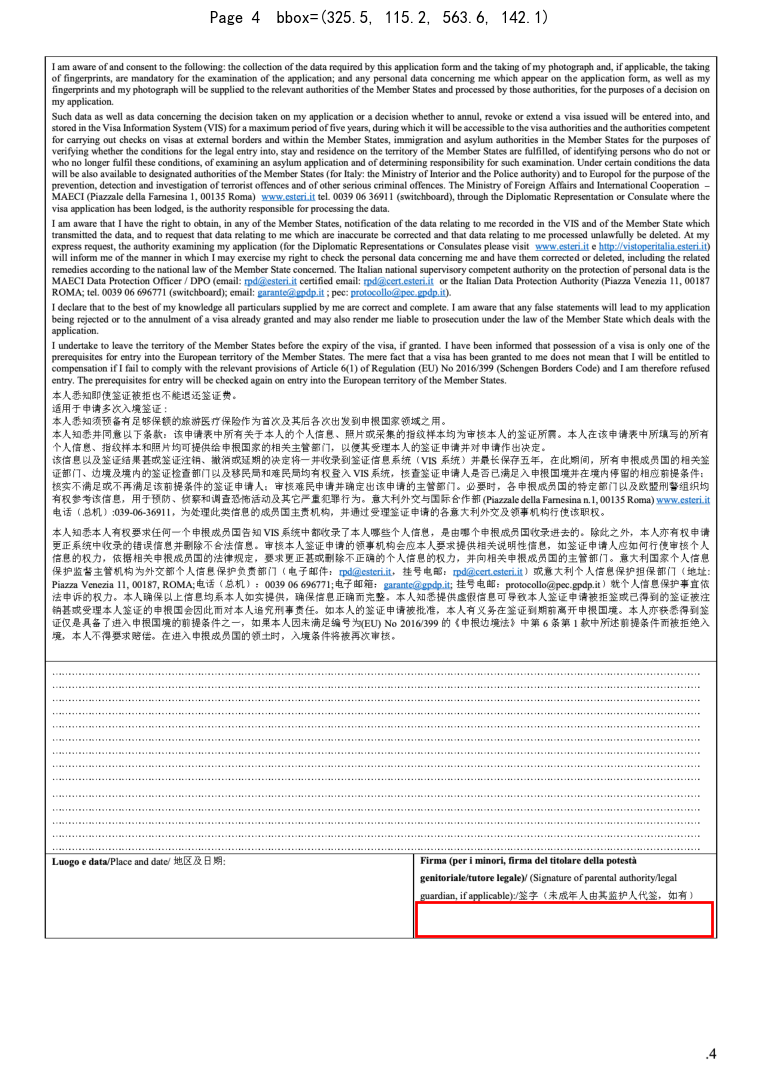

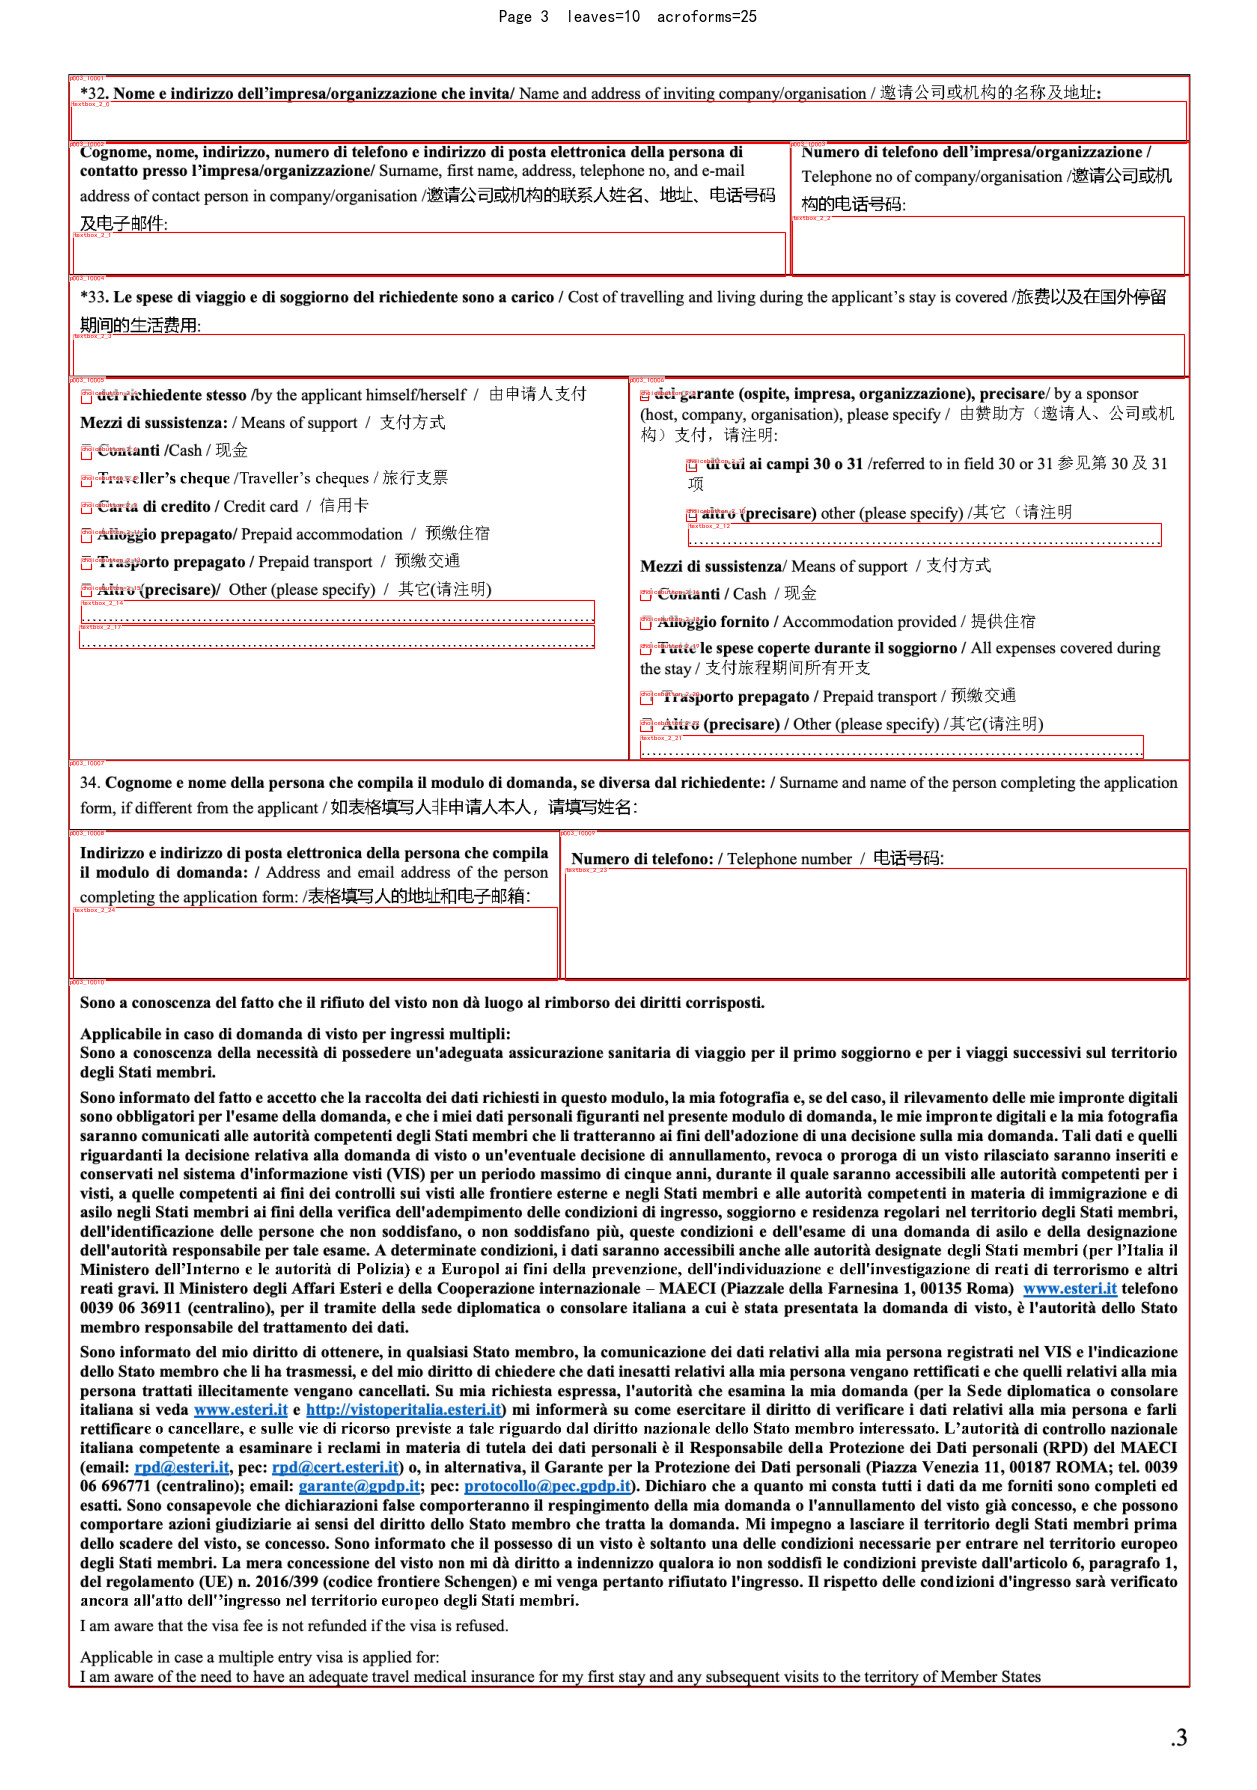

In [17]:
# ---------- Step 11: 在 notebook 中渲染指定页 + 高亮 bbox ----------
import matplotlib.pyplot as plt
import matplotlib.patches as patches

def show_box(pdf_path, page_no, bbox, resolution=150,
             color="red", linewidth=2, figsize=(8, 11)):
    """渲染指定页的图片，并在给定 bbox 上画高亮矩形。
       page_no: 1-based 页码
       bbox:    (x0, y0, x1, y1)，PDF 坐标（y 越大越靠上，与 page.rects 一致）
    """
    with pdfplumber.open(pdf_path) as pdf:
        page = pdf.pages[page_no - 1]
        page_h = page.height
        im = page.to_image(resolution=resolution).original  # PIL Image (top-left 原点)

    scale = resolution / 72.0     # PDF 坐标 → 图像像素
    x0, y0, x1, y1 = bbox

    # PDF 坐标 (左下原点) → 图像坐标 (左上原点)
    px0 = x0 * scale
    py0 = (page_h - y1) * scale
    pw  = (x1 - x0) * scale
    ph  = (y1 - y0) * scale

    fig, ax = plt.subplots(figsize=figsize)
    ax.imshow(im)
    ax.add_patch(patches.Rectangle(
        (px0, py0), pw, ph,
        linewidth=linewidth, edgecolor=color, facecolor="none",
    ))
    ax.set_title(f"Page {page_no}  bbox=({x0:.1f}, {y0:.1f}, {x1:.1f}, {y1:.1f})")
    ax.axis("off")
    plt.tight_layout()
    plt.show()


def show_page_annotations(pdf_path, page_no, parsed_pages,
                          resolution=200, linewidth=0.8, fontsize=5,
                          leaf_color="red", acroform_color="red",
                          figsize=(14, 18)):
    """渲染指定页的图片，把该页所有叶子节点和 AcroForm 都画成红框并标注名称。
       page_no:      1-based 页码
       parsed_pages: parse_pdf 返回的页列表
       叶子节点的标注使用 flatten_leaf_nodes 生成的 leaf_id，
       AcroForm 的标注使用其字段 name。
    """
    page_info = next((p for p in parsed_pages if p["page"] == page_no), None)
    if page_info is None:
        raise ValueError(f"page {page_no} not found in parsed_pages")

    with pdfplumber.open(pdf_path) as pdf:
        page = pdf.pages[page_no - 1]
        page_h = page.height
        im = page.to_image(resolution=resolution).original

    scale = resolution / 72.0
    leaves = flatten_leaf_nodes(page_info.get("trees", []), page_no)
    acroforms = extract_acroforms_by_page(pdf_path).get(page_no, [])

    fig, ax = plt.subplots(figsize=figsize)
    ax.imshow(im)

    def add_box(bbox, label, edgecolor, label_offset_y=0):
        x0, y0, x1, y1 = bbox
        px0 = x0 * scale
        py0 = (page_h - y1) * scale
        pw  = (x1 - x0) * scale
        ph  = (y1 - y0) * scale
        ax.add_patch(patches.Rectangle(
            (px0, py0), pw, ph,
            linewidth=linewidth, edgecolor=edgecolor, facecolor="none",
        ))
        if label:
            ax.text(
                px0 + 1, py0 + label_offset_y, str(label),
                fontsize=fontsize, color=edgecolor,
                ha="left", va="top",
                bbox=dict(facecolor="white", edgecolor="none", pad=0.5, alpha=0.65),
            )

    for leaf in leaves:
        add_box(leaf["bbox"], leaf.get("leaf_id", ""), leaf_color, label_offset_y=0)

    for form in acroforms:
        add_box(form["rect"], form.get("name", ""), acroform_color, label_offset_y=0)

    ax.set_title(
        f"Page {page_no}  leaves={len(leaves)}  acroforms={len(acroforms)}"
    )
    ax.axis("off")
    plt.tight_layout()
    plt.show()


# 示例：高亮 page 1 上的 [43.8, 87.0, 427.6, 121.2]
show_box(file, 4, ([
        325.51,
        115.2,
        563.63,
        142.08
      ]))

# 示例：在 page 1 上把所有叶子节点和 AcroForm 都标成红框
show_page_annotations(file, 3, pages)
